# Datos WCD LAGO
A continuación se muestra un ejemplo de como leer los archivos de datos generados por una de las aplicaciónes para capturar datos del Tanque Cherenkov de Agua del proyecto LAGO.

Primera se importan las librerías y clases que se van a utilizar. Para poder leer los archivos con extención __.paa__ en los que vienen los datos, se uiliza una clase __paa01File__ que está definida en el archivo _paa01_v2.py_ que se debe colocar en el mismo directorio o donde pueda ser encontrada.

In [4]:
import ROOT
from array import array
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from paa01_v2 import paaFile

Se crea una instancia de la clase __paaFile__ dando como argumento el nombre del archivo donde están los datos

In [5]:
DataFile = paaFile( "data/LA-mml-data_1h-180320-173703.paa" )

La clase __paaFile__ define varios métodos para obtener la información acerca de los datos contenidos en el archivo:
- __paaGetTextHeader( n )__ Devuelve la n-ésima línea de los encabezados de información del archivo. Cada archivo puede contener 5 lineas de encabezados. Estos encabezados contienen información de cuando se hicieron las mediciones, la versión del programa, una descripción de las mediciones hechas, etc.
- __paaGetPulseSize()__ Devuelve un entero que indica cuántos datos hay por cada pulso (evento) medido.
- __paaGetPulseCount()__ Devuelve un entero que indica cuántos pulsos (eventos) contiene el archivo.
- __paaGetThresholdLevel()__ Devuelve un entero que indica el valor de thershold, en unidades ADC, que fué utilizado para disparar la captura de datos.

In [6]:
print( DataFile.paaGetTextHeader(0) )
print( DataFile.paaGetTextHeader(1) )
print( DataFile.paaGetTextHeader(2) )
print( DataFile.paaGetTextHeader(3) )
print( DataFile.paaGetTextHeader(4) )


ps = DataFile.paaGetPulseSize()
pc = DataFile.paaGetPulseCount()
tl = DataFile.paaGetThresholdLevel()

print("Points per pulse: ", ps)
print("Pulses in this file: ", pc)
print("threshold level: ", tl)
print()

Pulse Acquire tool for Red Pitaya

Version: 0.1.0

Build: 20191018-164700-0600-040@BadWolf

Wed Mar 18 17:37:03 2020 UTC

"Muon Mean Life experiment from WCD pulses. PMT control voltage 1.50V, Gain LV"

Points per pulse:  1100
Pulses in this file:  59884
threshold level:  -150



Los datos del n-ésimo pulso (evento) se pueden obtener por medio del método __paaGetPulseRP( n )__. Este método devuelve los datos como un array unidimencional de python. 

## Ejemplo 1: Plotear los datos de un pulso del archivo utilizando matplotlib. 

Los datos del archivo son solo de voltaje en unidades ADC, no se incluye la información del tiempo ya que el muestreo se realiza a una frecuencia constante de 125 MSPS, esto es, cada 8 ns. Entonces, para plotear, hay que generar un array de "tiempo" o simplemente un índice del tamaño de la captura de datos:

In [7]:
pulse_data_t = list(range( ps ))

Luego se obtienen los datos como una lista y se plotean. En este caso también se mostrará una línea indicando el nivel de threshold utilizado:

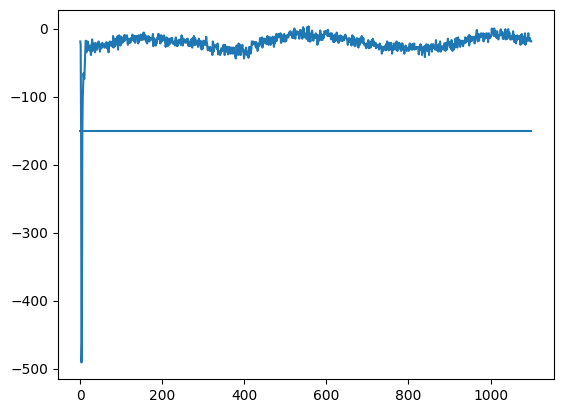

In [11]:
pulse_data_v = DataFile.paaGetPulseRP(250)

plt.plot(pulse_data_t, pulse_data_v)

ax = plt.gca()
ax.add_line( mlines.Line2D([0,ps-1], [tl,tl] ) )

plt.show()

## Ejemplo 2: Obtener un histograma del valor promedio los pulsos
También se puede iterar sobre el archivo y obtener los datos de los pulsos, en este caso son devueltos como un array de numpy.

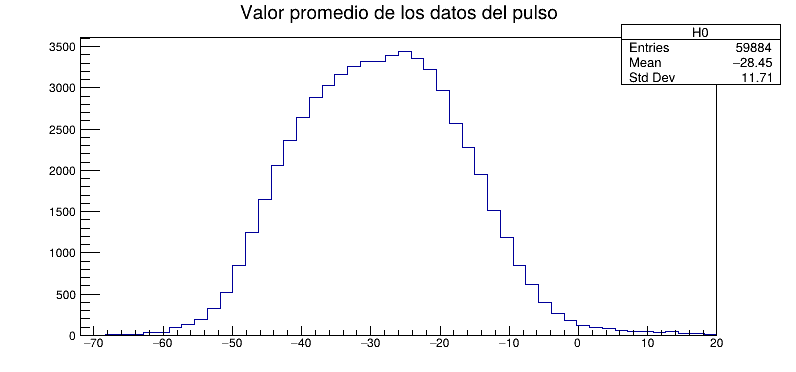

In [9]:
Mean_Hist = ROOT.TH1D("H0","Valor promedio de los datos del pulso",50,0,0)

for pulse_data_v_iter in DataFile:
    Mean_Hist.Fill( np.average( pulse_data_v_iter ) )

canvas = ROOT.TCanvas("C0", "Un Lienzo", 800, 400 )
Mean_Hist.Draw()
canvas.Draw()
